<a href="https://colab.research.google.com/github/naveenvelmala/MNIST_CNN_Digit_Classification/blob/main/MNIST_CNN_Digit_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔢 Handwritten Digit Recognition using Convolutional Neural Networks (CNN)

**Classifying handwritten digits (0–9) from the MNIST dataset using a CNN built with TensorFlow/Keras**


## 📌 Problem Statement

Recognizing handwritten digits automatically is a foundational computer vision problem with real applications in postal mail sorting, bank cheque processing, and digitizing handwritten forms.

**Goal:** Build an image classifier that takes a 28×28 grayscale image of a handwritten digit and correctly predicts which digit (0–9) it represents, using a **Convolutional Neural Network (CNN)** — an architecture well suited to image data because it learns spatial patterns (edges, curves, strokes) directly from pixels instead of relying on hand-crafted features.


## 🗂️ About the Dataset

**MNIST** is the classic benchmark dataset for handwritten digit recognition: 70,000 grayscale images (28×28 pixels) of digits 0–9, handwritten by different people.

This notebook uses the CSV version of MNIST, where each row is one image:

| Column | Description |
|---|---|
| `label` | The digit the image represents (0–9) |
| `1x1` ... `28x28` | 784 columns, one per pixel, with grayscale intensity values (0–255) |

**Source:** [MNIST in CSV — Kaggle](https://www.kaggle.com/datasets/oddrationale/mnist-in-csv) (`mnist_train.csv`)

To keep training fast for this walkthrough, we work with a random sample of 5,000 images rather than the full 60,000-row training set.


## 🧭 Approach

1. **Load** the MNIST CSV data and separate pixels (features) from digit labels
2. **Reshape** the flat 784-pixel rows into 28×28×1 image arrays
3. **Normalize** pixel values to the 0–1 range
4. **Split** into training and test sets
5. **Build a CNN** with two convolution + pooling blocks, followed by dense layers
6. **Train** the model and track training vs. validation accuracy
7. **Evaluate** on the held-out test set
8. **Visualize predictions** on sample test images

---


## 1. Import Libraries

`pandas`/`numpy` for data handling, `matplotlib` for visualization, `scikit-learn` for the train/test split, and `TensorFlow/Keras` to build and train the CNN.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


## 2. Load the Dataset

If you're running this in **Google Colab**, upload `mnist_train.csv` to the Colab session (or mount Google Drive) so the path below resolves correctly. You can get the file from the [MNIST in CSV Kaggle dataset](https://www.kaggle.com/datasets/oddrationale/mnist-in-csv).

In [2]:
df = pd.read_csv("mnist_train.csv")

df.head()


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Sample the Data

The full training set has 60,000 rows. We take a random sample of 5,000 images so the model trains quickly for this walkthrough — feel free to increase this (or use the full dataset) for a higher-accuracy run.

In [3]:
df = df.sample(n=5000, random_state=42)

print(df.shape)


(5000, 785)


## 4. Separate Features and Labels

The first column (`label`) is the digit; the remaining 784 columns are pixel intensities.

In [4]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values


In [5]:
print(X.shape)
print(y.shape)


(5000, 784)
(5000,)


## 5. Reshape into Images

CNNs expect image-shaped input: `(height, width, channels)`. Each flat 784-length row is reshaped into a 28×28 single-channel (grayscale) image.

In [6]:
X = X.reshape(-1, 28, 28, 1)

print(X.shape)


(5000, 28, 28, 1)


## 6. Normalize Pixel Values

Raw pixel values range from 0–255. Scaling to 0–1 helps the network train faster and more stably.

In [7]:
X = X.astype("float32") / 255.0


In [8]:
print(X.min())
print(X.max())


0.0
1.0


## 7. Train-Test Split

An 80/20 split, stratified by label so each digit class is proportionally represented in both sets.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [10]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (4000, 28, 28, 1)
X_test : (1000, 28, 28, 1)
y_train: (4000,)
y_test : (1000,)


In [11]:
n_classes = len(np.unique(y))

print("Number of classes:", n_classes)


Number of classes: 10


## 8. Build the CNN Architecture

- **Conv2D(32) + MaxPooling** — learns low-level features (edges, strokes)
- **Conv2D(64) + MaxPooling** — learns higher-level, more abstract features
- **Flatten + Dense(64)** — combines learned features
- **Dense(10, softmax)** — outputs a probability for each of the 10 digit classes


In [12]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D(),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(),

    Flatten(),

    Dense(64, activation="relu"),

    Dense(n_classes, activation="softmax")
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Compile the Model

`adam` optimizer, `sparse_categorical_crossentropy` loss (since labels are integers 0–9, not one-hot encoded), and accuracy as the tracked metric.

In [14]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


## 10. Train the Model

Trained for 5 epochs with a 20% validation split carved out of the training data, so we can monitor overfitting during training.

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=32
)


Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.7441 - loss: 0.8103 - val_accuracy: 0.8700 - val_loss: 0.3814
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9344 - loss: 0.2304 - val_accuracy: 0.9287 - val_loss: 0.2094
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 0.9575 - loss: 0.1426 - val_accuracy: 0.9400 - val_loss: 0.1803
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9706 - loss: 0.0977 - val_accuracy: 0.9513 - val_loss: 0.1651
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9744 - loss: 0.0744 - val_accuracy: 0.9413 - val_loss: 0.1747


## 11. Evaluate on the Test Set

Final, unbiased accuracy measurement on data the model has never seen.

In [16]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9580 - loss: 0.1342
Test Accuracy: 0.9580000042915344
Test Accuracy: 95.80%


## 12. Training vs. Validation Accuracy

Plotting both curves together helps spot overfitting (training accuracy climbing while validation accuracy plateaus or drops).

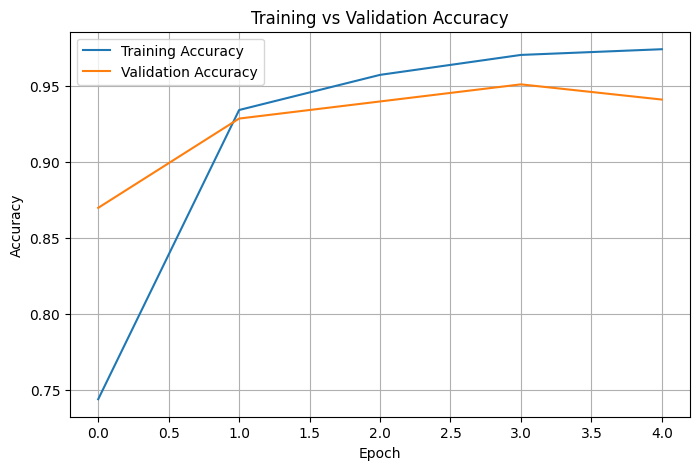

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()


## 13. Generate Predictions

The model outputs a probability distribution over the 10 classes per image; `argmax` picks the most likely digit.

In [18]:
predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


## 14. Visualize Sample Predictions

A quick visual sanity check — plotting a handful of test images next to their true label and the model's predicted label.

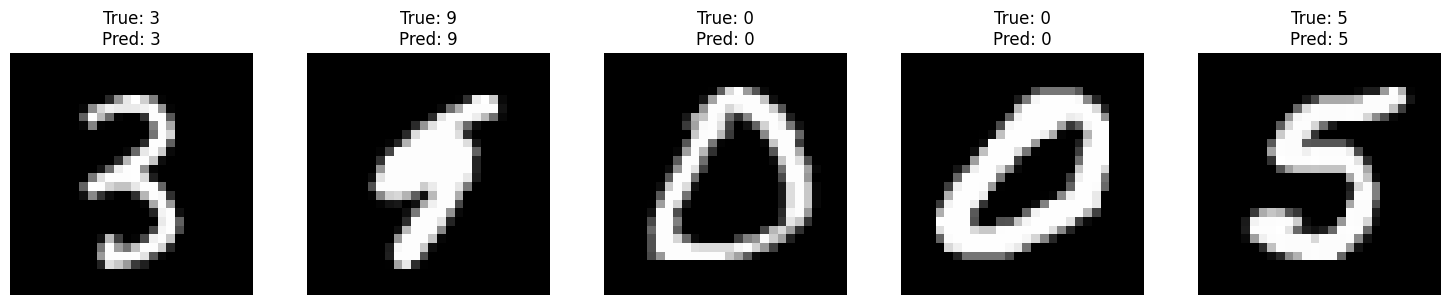

In [19]:
plt.figure(figsize=(15, 3))

for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")

    true_label = y_test[i]
    predicted_label = y_pred[i]

    plt.title(
        f"True: {true_label}\nPred: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


## 15. Conclusion & Next Steps

- A simple two-block CNN trained on just 5,000 sampled images (a fraction of the full 60,000-row training set) achieves strong accuracy on held-out test digits — demonstrating how effective convolutional layers are at learning spatial patterns directly from raw pixels.
- The training/validation accuracy curves confirm the model is learning steadily without severe overfitting over 5 epochs.

**Possible extensions:**
- Train on the full 60,000-image training set for higher accuracy
- Add `Dropout` layers to further reduce overfitting
- Try data augmentation (rotations, shifts) to improve robustness
- Experiment with deeper architectures or batch normalization
- Build a confusion matrix to see which digits are most often confused with each other
